# Homework 5

The purpose of this homework is to advance your final project in a structured way in order to get feedback from the teaching team early. 

For this homework you have three main goals: 
* Build out the motivation for your study
* Refine your research question
* Collect and clean all of your data

There will be **two deliverables that you will upload to Canvas**: 
1. A powerpoint presentation draft of the motivation and research question. 
2. This .ipynb of any necessary data collecting and cleaning

By the end of this homework assignment, you should have a clear story of why you are pursuing this question, what the question is, and fully cleaned data ready for analysis.

## Instructions for the Powerpoint

### Motivation section

Build a draft of the opening slides of your final presentation. These should cover: 
* The big picture problem you are trying to solve and why its important (This is very important!)
* What we know now about the question and what open questions remain (Convince us that this hasn't been done yet)
* The real world context of your study (Nobody else in the room knows the context of your study as well as you!)
* Your research question 

Tips for effective slides:
- **Minimize use of text**. Use text to enhance your slides, don't rely on it. You should not have paragraphs of text on your slides. Think punchy statements that compliment your voice tract.
- **Use some text**. Conversely, slides that have one big image of a butterfly and no context are not useful. You want your slides to standalone even without you talking. This is a delicate balance!
- **Use color and bolding to emphasize key points**. What are the key phrases we need to remember or focus on? Use text to highlight these phrases.
- **Treat your slides like a story**. This is not a journal article in visual format. This is a sales pitch for why we should care about your research.

There is not a hard and fast limit to the number of slides this should be. However, it should, in minutes, take about 3-4 minutes of a 10 minute talk. Depending on how you like to build slides, the number this works out to be is up to you. 

## Instructions for the .ipynb Code

In the following cells, add code to collect and clean all of the data you need. Remember you need at least two different data sources for the final project. 

If you collect your data from somewhere else, add markdown comments to explain where you got it, and what is represented inside the dataset. If you collect your data through APIs, add the code here. 

For any cleaning steps necessary, investigate the data to see what the columns hold, determine if you need to exclude or modify any rows, and do any merging or joining necessary. You should end up with the final datasets you need in order to run your analysis. Save these cleaned files for later use. 

In every cell block, make sure to add adequate comments such that someone else could run your code and understand the purpose if needed. For longer explanations, use markdown language or full docstring comments. 

In [56]:
!pip install mapclassify


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [162]:
import pandas as pd
import geopandas as gpd
import numpy as np 
import statsmodels.formula.api as smf
from us import states
import matplotlib.pyplot as plt
from libpysal import io
from libpysal import weights
import osmnx as ox
from key import CENSUS_KEY
from census import Census
import networkx as nx

In [163]:
c = Census(CENSUS_KEY)

In [164]:
variables = {'B02001_001E': 'Total Population',
    'B19301_001E': 'Per Capita Income',
    'B02001_002E': 'White Population',
    'B17001_001E': 'Population Measured for Poverty Status',
    'B17001_002E': 'People Below Poverty Level',
    'B25003_001E': 'Occupied_units',
    'B25003_003E': 'Renter_occupied_units'}   # ← NEW: tenure variable

ny_tracts = c.acs5.get(
    list(variables.keys()),
    {'for': 'tract:*', 
     'in': 'state:36 county:061'}, 
    year=2020,
)

## Comment: Need to decide which variables we are gonna add
## renter-occupied units added for tenure analysis

In [165]:
ny_df = pd.DataFrame(ny_tracts)
ny_df = ny_df.rename(columns=variables)
ny_df['GEOID'] = ny_df['state'] + ny_df['county'] + ny_df['tract']

# Replace Census missing-data sentinel values with NaN before doing any math.
# Census uses -666666666 (and similar) for tracts where data is unavailable
# (parks, water, airports, zero-population tracts). Treating these as real
# numbers would corrupt downstream calculations (e.g. the log transform).
acs_numeric_cols = ['Total Population', 'Per Capita Income', 'White Population',
                    'Population Measured for Poverty Status', 'People Below Poverty Level',
                    'Occupied_units', 'Renter_occupied_units']
for col in acs_numeric_cols:
    ny_df[col] = pd.to_numeric(ny_df[col], errors='coerce')
    ny_df.loc[ny_df[col] < 0, col] = np.nan

# Now build the percentage variables
ny_df["white_share_pct"]    = ny_df["White Population"] / ny_df["Total Population"] * 100
ny_df["nonwhite_share_pct"] = 100 - ny_df["white_share_pct"]
ny_df["poverty_rate_pct"]   = ny_df["People Below Poverty Level"] / ny_df["Population Measured for Poverty Status"] * 100
ny_df["renter_share_pct"]   = ny_df["Renter_occupied_units"] / ny_df["Occupied_units"] * 100

ny_df.head()

## Comment: Rename ACS variable codes into readable names.
## Replace Census missing-data sentinels (-666666666 etc.) with NaN.
## Build GEOID and key percentage variables. 
## Column names use _pct instead of (%) so they work in statsmodels formulas later.

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,Renter_occupied_units,state,county,tract,GEOID,white_share_pct,nonwhite_share_pct,poverty_rate_pct,renter_share_pct
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,1784.0,36,061,016500,36061016500,81.285586,18.714414,9.439616,56.171285
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,2631.0,36,061,016600,36061016600,47.050983,52.949017,30.262046,94.098712
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,1801.0,36,061,016700,36061016700,86.431165,13.568835,9.227468,60.660155
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,1647.0,36,061,016800,36061016800,33.166313,66.833687,43.342037,92.841037
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,2823.0,36,061,016900,36061016900,83.353482,16.646518,10.480722,71.486452


In [168]:
year = 2020
state_fips = "36"

url = f"https://www2.census.gov/geo/tiger/TIGER{year}/TRACT/tl_{year}_{state_fips}_tract.zip"

tracts = gpd.read_file(url)
tracts = tracts.to_crs(epsg=4326)
tracts.head()

## Comment: Set the year and New York State FIPS code.
## Build the shapefile URL from the Census TIGER/Line website.
## Read the tract geometries into a GeoDataFrame.
## Reproject the data to EPSG:4326.
## Prepare the tract boundary data for later filtering and merging

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,36,047,000700,36047000700,7,Census Tract 7,G5020,S,176774,0,+40.6923505,-073.9973434,"POLYGON ((-74.00154 40.69279, -74.00132 40.693..."
1,36,047,000900,36047000900,9,Census Tract 9,G5020,S,163469,0,+40.6917206,-073.9916018,"POLYGON ((-73.99405 40.6909, -73.99374 40.6915..."
2,36,047,001100,36047001100,11,Census Tract 11,G5020,S,168507,0,+40.6932903,-073.9877087,"POLYGON ((-73.99073 40.69305, -73.99045 40.693..."
3,36,047,001300,36047001300,13,Census Tract 13,G5020,S,293167,0,+40.6976150,-073.9883586,"POLYGON ((-73.99141 40.69863, -73.99131 40.699..."
4,36,047,002000,36047002000,20,Census Tract 20,G5020,S,154138,0,+40.6480407,-074.0159276,"POLYGON ((-74.01867 40.64741, -74.01809 40.647..."


In [169]:
ny_df_tracts = pd.merge(left=ny_df, right=tracts, on='GEOID', how='left')
ny_df_tracts.head()
## Comment: matches the two datasets by tract ID,
## keeps all rows from the social data,
## attaches tract geometries for later spatial analysis.

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,Renter_occupied_units,state,county,tract,...,TRACTCE,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,1784.0,36,061,016500,...,016500,165,Census Tract 165,G5020,S,204327,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783..."
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,2631.0,36,061,016600,...,016600,166,Census Tract 166,G5020,S,174218,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891..."
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,1801.0,36,061,016700,...,016700,167,Census Tract 167,G5020,S,196979,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790..."
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,1647.0,36,061,016800,...,016800,168,Census Tract 168,G5020,S,199278,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790..."
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,2823.0,36,061,016900,...,016900,169,Census Tract 169,G5020,S,180003,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786..."


In [175]:
# Population density (people per km^2)
ny_df_tracts["ALAND"] = ny_df_tracts["ALAND"].astype(float)
ny_df_tracts["pop_density"] = ny_df_tracts["Total Population"] / (ny_df_tracts["ALAND"] / 1e6)

# Log transforms — both variables are heavily right-skewed in Manhattan.
# Manhattan tract incomes range from ~$10k to $300k+, and densities from
# near-zero (parks) to 100,000+ /km^2 (Upper East Side).
# We use log(x + 1) to handle zero values; tracts with NaN in the source
# (e.g. zero-population park tracts) will propagate to NaN, which is fine —
# they're dropped from the regression by H.1's dropna() anyway.

ny_df_tracts["log_pop_density"]       = np.log(ny_df_tracts["pop_density"] + 1)
ny_df_tracts["log_per_capita_income"] = np.log(ny_df_tracts["Per Capita Income"] + 1)

# Quick check
ny_df_tracts[["GEOID", "Per Capita Income", "log_per_capita_income",
              "pop_density", "log_pop_density"]].describe().round(2)

,Per Capita Income,log_per_capita_income,pop_density,log_pop_density
count,303.00,303.00,310.00,310.00
mean,83989.55,11.09,34898.12,10.05
std,52973.23,0.78,18812.55,1.70
min,1352.00,7.21,0.00,0.00
25%,37822.50,10.54,22543.96,10.02
50%,75265.00,11.23,34857.94,10.46
75%,121442.00,11.71,44564.63,10.70
max,302988.00,12.62,120134.70,11.70


In [176]:
# Diagnostic: where is the contamination?
print("=== ny_df['Per Capita Income'] (after cell 6) ===")
print(ny_df['Per Capita Income'].describe().round(2))
print()
print("=== ny_df_tracts['Per Capita Income'] (after merge + pop_density cell) ===")
print(ny_df_tracts['Per Capita Income'].describe().round(2))

=== ny_df['Per Capita Income'] (after cell 6) ===
count       303.00
mean      83989.55
std       52973.23
min        1352.00
25%       37822.50
50%       75265.00
75%      121442.00
max      302988.00
Name: Per Capita Income, dtype: float64

=== ny_df_tracts['Per Capita Income'] (after merge + pop_density cell) ===
count       303.00
mean      83989.55
std       52973.23
min        1352.00
25%       37822.50
50%       75265.00
75%      121442.00
max      302988.00
Name: Per Capita Income, dtype: float64


In [177]:
ny_df_tracts = gpd.GeoDataFrame(ny_df_tracts)
ny_df_tracts.crs = 'EPSG:4326'

In [178]:
ny_df_tracts['centroid'] = ny_df_tracts['geometry'].centroid
ny_df_tracts.head()

C:\Users\gjx30\AppData\Local\Temp\ipykernel_37584\2057361798.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ny_df_tracts['centroid'] = ny_df_tracts['geometry'].centroid


,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,Renter_occupied_units,state,county,tract,...,AWATER,INTPTLAT,INTPTLON,geometry,centroid,x,y,pop_density,log_pop_density,log_per_capita_income
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,1784.0,36,061,016500,...,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,32663.328880,10.394039,12.025851
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,2631.0,36,061,016600,...,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,34451.090014,10.447325,10.407017
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,1801.0,36,061,016700,...,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,30754.547439,10.333826,11.894330
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,1647.0,36,061,016800,...,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,26039.000793,10.167389,10.621279
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,2823.0,36,061,016900,...,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,45954.789642,10.735435,11.614444


In [179]:
ny_df_tracts['x'] = ny_df_tracts['centroid'].x
ny_df_tracts['y'] = ny_df_tracts['centroid'].y
ny_df_tracts.head()

## Comment:Generate x and y columns from the centroid (Later will be used to identify the nearest nodes).

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,Renter_occupied_units,state,county,tract,...,AWATER,INTPTLAT,INTPTLON,geometry,centroid,x,y,pop_density,log_pop_density,log_per_capita_income
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,1784.0,36,061,016500,...,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,32663.328880,10.394039,12.025851
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,2631.0,36,061,016600,...,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,34451.090014,10.447325,10.407017
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,1801.0,36,061,016700,...,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,30754.547439,10.333826,11.894330
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,1647.0,36,061,016800,...,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,26039.000793,10.167389,10.621279
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,2823.0,36,061,016900,...,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,45954.789642,10.735435,11.614444


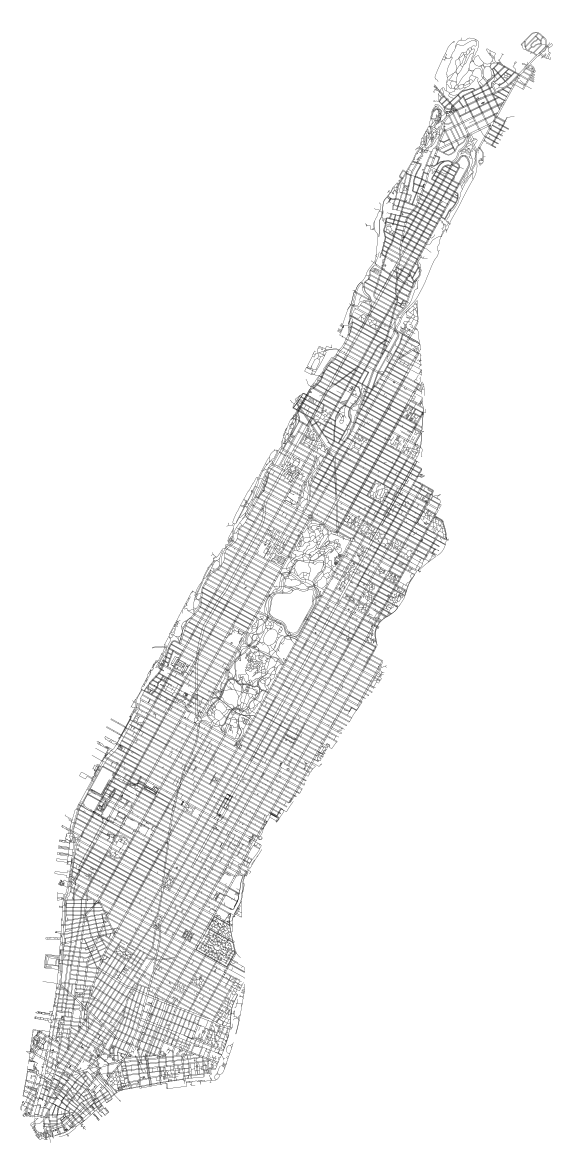

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [180]:
place = "Manhattan, New York, USA"
A = ox.graph.graph_from_place(place, network_type = "walk")
fig, ax = plt.subplots(figsize = (15,15))
ox.plot.plot_graph(A, bgcolor = "white", node_color = "black", edge_color = "black", node_size = 0, edge_linewidth = 0.1, ax=ax)

## Comment:defines Manhattan as the study area,
## downloads the walkable street network,
## plots the network for a quick visual check.

In [181]:
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(A)
gdf_nodes.head()

,y,x,street_count,highway,ref,railway,geometry
osmid,,,,,,,
30807314,40.790720,-73.963576,4,NaN,NaN,NaN,POINT (-73.96358 40.79072)
30978747,40.774267,-73.973425,4,NaN,NaN,NaN,POINT (-73.97342 40.77427)
30978752,40.774769,-73.974393,4,NaN,NaN,NaN,POINT (-73.97439 40.77477)
42421728,40.798048,-73.960044,1,traffic_signals,NaN,NaN,POINT (-73.96004 40.79805)
42421783,40.859329,-73.931324,1,traffic_signals,NaN,NaN,POINT (-73.93132 40.85933)


In [182]:
gdf_edges['speed_kph'] = 5
A = ox.convert.graph_from_gdfs(gdf_nodes, gdf_edges)
A = ox.routing.add_edge_travel_times(A)

## Comment:Set walking speed to 5km/h.
## Then added travel times based on the walking speed.

In [183]:
print(ny_df_tracts.columns.tolist())

['Total Population', 'Per Capita Income', 'White Population', 'Population Measured for Poverty Status', 'People Below Poverty Level', 'Occupied_units', 'Renter_occupied_units', 'state', 'county', 'tract', 'GEOID', 'white_share_pct', 'nonwhite_share_pct', 'poverty_rate_pct', 'renter_share_pct', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'centroid', 'x', 'y', 'pop_density', 'log_pop_density', 'log_per_capita_income']


In [184]:
tract_nodes = ox.distance.nearest_nodes(A, ny_df_tracts['x'], ny_df_tracts['y'])
tract_nodes = list(tract_nodes)
ny_df_tracts["nearest_nodes"] = tract_nodes
ny_df_tracts.head()

## Comment:Identify all the nodes thar are closest to the tract centroids, and made them into a list.
## Then added them into our ny_df_tracts DataFrame.

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,Renter_occupied_units,state,county,tract,...,INTPTLAT,INTPTLON,geometry,centroid,x,y,pop_density,log_pop_density,log_per_capita_income,nearest_nodes
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,1784.0,36,061,016500,...,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,32663.328880,10.394039,12.025851,9897810856
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,2631.0,36,061,016600,...,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,34451.090014,10.447325,10.407017,8732555179
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,1801.0,36,061,016700,...,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,30754.547439,10.333826,11.894330,2329911477
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,1647.0,36,061,016800,...,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,26039.000793,10.167389,10.621279,6254630515
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,2823.0,36,061,016900,...,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,45954.789642,10.735435,11.614444,10042554913


<Axes: >

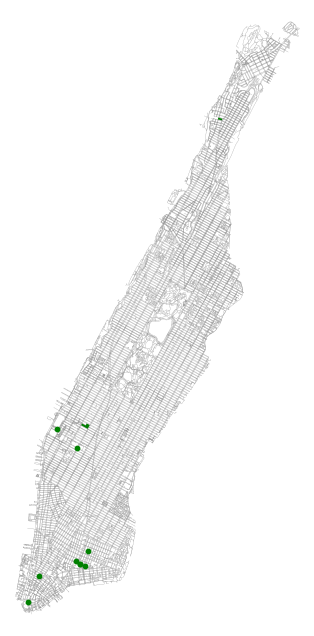

In [185]:
tags_busregional = {'amenity' : 'bus_station'}
gdf_busregional = ox.features.features_from_place(place, tags_busregional)
fig, ax = ox.plot.plot_graph(A, bgcolor = "white", node_size = 0, edge_linewidth = 0.1, show=False)
gdf_busregional.plot(ax=ax, color='green', markersize=10)

## Comment:defines the OSM tag for regional bus stations,
##  downloads the corresponding point features for Manhattan,
##  plots them on top of the walking network for a quick check.

In [186]:
gdf_busregional

geometry  \
element id                                                               
node    2554956151                          POINT (-73.99084 40.71959)   
        2567558455                          POINT (-73.99402 40.71566)   
        2902930629                          POINT (-74.00289 40.75607)   
        5028831921                          POINT (-73.99204 40.71506)   
        5093187022                          POINT (-74.01442 40.70405)   
        6458076485                          POINT (-74.00987 40.71209)   
        6867960885                          POINT (-73.99509 40.75029)   
        6910663883                          POINT (-73.99548 40.71635)   
        10683893736                         POINT (-73.99371 40.71557)   
way     108160358    POLYGON ((-73.99083 40.75609, -73.99338 40.757...   
        275061119    POLYGON ((-73.93779 40.84848, -73.93905 40.848...   

                    addr:city addr:housenumber addr:postcode addr:state  \
element id                                                                
node    2554956151   New York               62         10002         NY   
        2567558455        NaN              103         10002        NaN   
        2902930629   New York              NaN         10001         NY   
        5028831921        NaN              NaN           NaN        NaN   
        5093187022        NaN              NaN           NaN        NaN   
        6458076485        NaN              NaN           NaN        NaN   
        6867960885        NaN              NaN           NaN        NaN   
        6910663883        NaN              145           NaN        NaN   
        10683893736       NaN               95           NaN        NaN   
way     108160358    New York              625           NaN         NY   
        275061119    New York              NaN           NaN         NY   

                          addr:street      amenity  bus  \
element id                                                
node    2554956151    Delancey Street  bus_station  yes   
        2567558455       Canal Street  bus_station  yes   
        2902930629   West 34th Street  bus_station  yes   
        5028831921                NaN  bus_station  yes   
        5093187022                NaN  bus_station  yes   
        6458076485                NaN  bus_station  yes   
        6867960885                NaN  bus_station  yes   
        6910663883       Canal Street  bus_station  yes   
        10683893736      Canal Street  bus_station  yes   
way     108160358          8th Avenue  bus_station  yes   
        275061119                 NaN  bus_station  yes   

                                                     name            phone  \
element id                                                                   
node    2554956151                             D3 Busline  +1-646-210-8928   
        2567558455                            Wanda Coach  +1 917 717 4666   
        2902930629                                Megabus              NaN   
        5028831921                              Tiger Bus              NaN   
        5093187022                                    NaN              NaN   
        6458076485                             The Oculus              NaN   
        6867960885             FlixBus NYC 300 W 31st St.              NaN   
        6910663883                             Lucky Star  +1-617-269-5468   
        10683893736                           95 Bus Stop  +1 212-965-8880   
way     108160358             Port Authority Bus Terminal              NaN   
        275061119    George Washington Bridge Bus Station              NaN   

                     ... operator:wikidata short_name  start_date toilets  \
element id           ...                                                    
node    2554956151   ...               NaN        NaN         NaN     NaN   
        2567558455   ...               NaN        NaN         NaN     NaN   
        2902930629   ...        

In [187]:
gdf_busregional['centroid'] = gdf_busregional['geometry'].centroid
gdf_busregional['x'] = gdf_busregional['centroid'].x
gdf_busregional['y'] = gdf_busregional['centroid'].y
gdf_busregional.head()

C:\Users\gjx30\AppData\Local\Temp\ipykernel_37584\809056918.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_busregional['centroid'] = gdf_busregional['geometry'].centroid


geometry addr:city addr:housenumber  \
element id                                                                  
node    2554956151  POINT (-73.99084 40.71959)  New York               62   
        2567558455  POINT (-73.99402 40.71566)       NaN              103   
        2902930629  POINT (-74.00289 40.75607)  New York              NaN   
        5028831921  POINT (-73.99204 40.71506)       NaN              NaN   
        5093187022  POINT (-74.01442 40.70405)       NaN              NaN   

                   addr:postcode addr:state       addr:street      amenity  \
element id                                                                   
node    2554956151         10002         NY   Delancey Street  bus_station   
        2567558455         10002        NaN      Canal Street  bus_station   
        2902930629         10001         NY  West 34th Street  bus_station   
        5028831921           NaN        NaN               NaN  bus_station   
        5093187022           NaN        NaN               NaN  bus_station   

                    bus         name            phone  ... toilets  \
element id                                             ...           
node    2554956151  yes   D3 Busline  +1-646-210-8928  ...     NaN   
        2567558455  yes  Wanda Coach  +1 917 717 4666  ...     NaN   
        2902930629  yes      Megabus              NaN  ...     NaN   
        5028831921  yes    Tiger Bus              NaN  ...     NaN   
        5093187022  yes          NaN              NaN  ...     NaN   

                   toilets:fee wikidata wikimedia_commons wikipedia  \
element id                                                            
node    2554956151         NaN      NaN               NaN       NaN   
        2567558455         NaN      NaN               NaN       NaN   
        2902930629         NaN      NaN               NaN       NaN   
        5028831921         NaN      NaN               NaN       NaN   
        5093187022         NaN      NaN               NaN       NaN   

                   air_conditioning internet_access:ssid  \
element id                                                 
node    2554956151              NaN                  NaN   
        2567558455              NaN                  NaN   
        2902930629              NaN                  NaN   
        5028831921              NaN                  NaN   
        5093187022              NaN                  NaN   

                                      centroid          x          y  
element id                                                            
node    2554956151  POINT (-73.99084 40.71959) -73.990836  40.719586  
        2567558455  POINT (-73.99402 40.71566) -73.994023  40.715662  
        2902930629  POINT (-74.00289 40.75607) -74.002890  40.756073  
        5028831921  POINT (-73.99204 40.71506) -73.992039  40.715063  
        5093187022  POINT (-74.01442 40.70405) -74.014416  40.704055  

[5 rows x 49 columns]

In [188]:
busregional_nodes = ox.distance.nearest_nodes(A, gdf_busregional['x'], gdf_busregional['y'])
busregional_nodes = list(busregional_nodes)
busregional_nodes
## Comment:Identify all the nodes thar are closest to the regional bus stops, and made them into a list.

[np.int64(8307642249),
 np.int64(4528918669),
 np.int64(593909360),
 np.int64(13068225207),
 np.int64(5037087617),
 np.int64(8262936509),
 np.int64(6814312333),
 np.int64(4528918665),
 np.int64(11826558566),
 np.int64(9201440708),
 np.int64(12925573366)]

In [189]:
nearest_time = nx.multi_source_dijkstra_path_length(A, busregional_nodes, weight = "travel_time")

## Comment:Get the nearest distance to the regional bus stop for every node in graph A.

In [190]:
tract_to_busregional = {a: nearest_time.get(a) for a in tract_nodes}
tract_to_busregional

## Comment:This is extracting only the nodes we identified that should be near the census tract centroids.

{np.int64(9897810856): 2396.3697849080804,
 np.int64(8732555179): 4323.187721761324,
 np.int64(2329911477): 2888.436985191023,
 np.int64(6254630515): 4113.925076270941,
 np.int64(10042554913): 2631.999518315057,
 np.int64(4207779531): 4851.450102282958,
 np.int64(2329911577): 2948.1019600291374,
 np.int64(7779608818): 4687.387382807042,
 np.int64(10057068492): 2867.246603528546,
 np.int64(6256723782): 4467.182883791813,
 np.int64(7803460155): 4649.156570462613,
 np.int64(2967753947): 3138.5672771400923,
 np.int64(10060974811): 3107.487790471687,
 np.int64(7925259044): 5465.211376812093,
 np.int64(2329911741): 3485.258355842752,
 np.int64(7924346731): 5160.575830355023,
 np.int64(8687882783): 3327.830929821122,
 np.int64(10122953002): 4768.217791091155,
 np.int64(2329798594): 3700.2900503005894,
 np.int64(10167086797): 4551.686565423943,
 np.int64(4111310274): 3492.340997319465,
 np.int64(6223478838): 4455.39083497525,
 np.int64(1684212082): 4008.1349624217264,
 np.int64(10170834282): 4

In [191]:
tract_to_busregional = pd.DataFrame(list(tract_to_busregional.items()))
tract_to_busregional.head()

## Comment:We then changed it into a DataFrame.

,0,1
0,9897810856,2396.369785
1,8732555179,4323.187722
2,2329911477,2888.436985
3,6254630515,4113.925076
4,10042554913,2631.999518


In [192]:
# Rename to a mode-specific column so later merges don't collide across modes.
# Keep travel time in seconds (the unit returned by Dijkstra with weight='travel_time').
tract_to_busregional = tract_to_busregional.rename(columns = {
                        0: "nearest_nodes",
                        1: "tt_busregional_sec"}
)
tract_to_busregional.sort_values(by="tt_busregional_sec")

## Comment: Renamed columns. tt_busregional_sec is walking travel time in seconds
## from each tract centroid's nearest node to the nearest regional bus station.

## Comment:Renamed the columns, and then sorted by travel time (in seconds)

,nearest_nodes,tt_busregional_sec
134,11826558566,0.000000
135,12993686212,70.242681
221,247075502,141.816744
94,9566938931,164.708421
117,5816038508,188.921929
...,...,...
27,7927125723,4968.621269
23,10170834282,4995.140788
15,7924346731,5160.575830
79,371218803,5298.101629


In [193]:
tract_busregional = pd.merge(left=ny_df_tracts, right=tract_to_busregional, on='nearest_nodes', how='left')
tract_busregional.head()

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,Renter_occupied_units,state,county,tract,...,INTPTLON,geometry,centroid,x,y,pop_density,log_pop_density,log_per_capita_income,nearest_nodes,tt_busregional_sec
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,1784.0,36,061,016500,...,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,32663.328880,10.394039,12.025851,9897810856,2396.369785
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,2631.0,36,061,016600,...,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,34451.090014,10.447325,10.407017,8732555179,4323.187722
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,1801.0,36,061,016700,...,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,30754.547439,10.333826,11.894330,2329911477,2888.436985
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,1647.0,36,061,016800,...,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,26039.000793,10.167389,10.621279,6254630515,4113.925076
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,2823.0,36,061,016900,...,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,45954.789642,10.735435,11.614444,10042554913,2631.999518


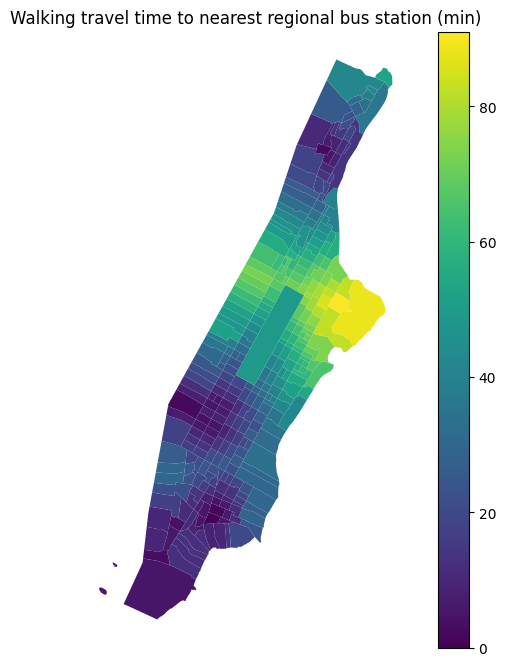

In [194]:
tract_busregional["tt_busregional_min"] = tract_busregional["tt_busregional_sec"] / 60
fig, ax = plt.subplots(figsize=(8, 8))
tract_busregional.plot(
    column='tt_busregional_min',
    legend=True,
    cmap='viridis',
    ax=ax,)
ax.set_title("Walking travel time to nearest regional bus station (min)")
ax.set_axis_off()
# Add a minute version of travel time for readable maps and reporting.

In [195]:
def compute_mode_accessibility(gdf_mode, mode_name, A=A, ny_df_tracts=ny_df_tracts, tract_nodes=tract_nodes):
    """
    Compute walking travel time from each tract centroid to the nearest mode point.

    Pipeline (same as the regional-bus block in Cell 16-24):
      1. Take centroid (x, y) of each mode feature.
      2. Snap each mode feature to its nearest walking-graph node.
      3. Run multi-source Dijkstra with weight='travel_time' from all mode nodes.
      4. For each tract centroid's nearest node, look up the resulting travel time.
      5. Return a small DataFrame keyed by 'nearest_nodes' with one travel-time column.

    Parameters
    ----------
    gdf_mode : GeoDataFrame
        OSM features for the mode (e.g., gdf_buslocal, gdf_subway, gdf_bicycle).
    mode_name : str
        Short name used in the output column, e.g., 'buslocal', 'subway', 'bike'.
    A : networkx graph
        The Manhattan walking graph with travel_time on edges.
    ny_df_tracts : GeoDataFrame
        Tract dataframe (only used for length sanity checks).
    tract_nodes : list
        List of nearest-node IDs for tract centroids (already built in Cell 15).

    Returns
    -------
    DataFrame with columns ['nearest_nodes', f'tt_{mode_name}_sec'].
    """

    # 1. Take centroids of mode features (some OSM features are polygons, so .centroid is safer).
    gdf = gdf_mode.copy()
    gdf['centroid'] = gdf['geometry'].centroid
    gdf['x'] = gdf['centroid'].x
    gdf['y'] = gdf['centroid'].y

    # 2. Snap mode features to nearest graph nodes
    mode_nodes = ox.distance.nearest_nodes(A, gdf['x'], gdf['y'])
    mode_nodes = list(mode_nodes)

    # 3. Multi-source Dijkstra: shortest travel time from any mode node to every node in A
    nearest_time = nx.multi_source_dijkstra_path_length(A, mode_nodes, weight="travel_time")

    # 4. Pull travel time for each tract's nearest node
    tract_to_mode = {a: nearest_time.get(a) for a in tract_nodes}
    tract_to_mode = pd.DataFrame(list(tract_to_mode.items()))
    tract_to_mode = tract_to_mode.rename(columns={0: "nearest_nodes",
                                                  1: f"tt_{mode_name}_sec"})

    return tract_to_mode

## Comment: Reusable function that wraps the proven regional-bus pipeline.
## Same syntax (ox.distance.nearest_nodes + nx.multi_source_dijkstra_path_length).
## Output is a small DataFrame ready to merge onto ny_df_tracts via 'nearest_nodes'.

<Axes: >

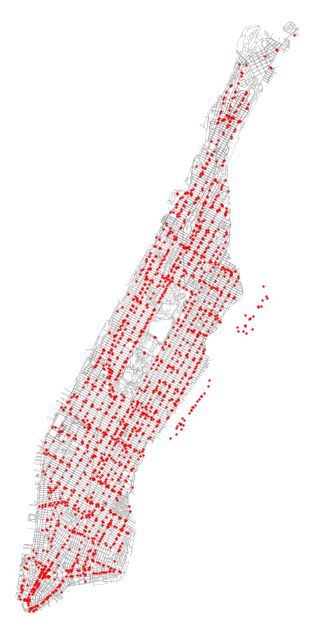

In [196]:
tags_buslocal = {'highway' : 'bus_stop'}
gdf_buslocal = ox.features.features_from_place(place, tags_buslocal)
fig, ax = ox.plot.plot_graph(A, bgcolor = "white", node_size = 0, edge_linewidth = 0.1, show=False)
gdf_buslocal.plot(ax=ax, color='red', markersize=0.5)

## Comment:defines the OSM tag for local bus stations,
##  downloads the corresponding point features for Manhattan,
##  plots them on top of the walking network for a quick check.

<Axes: >

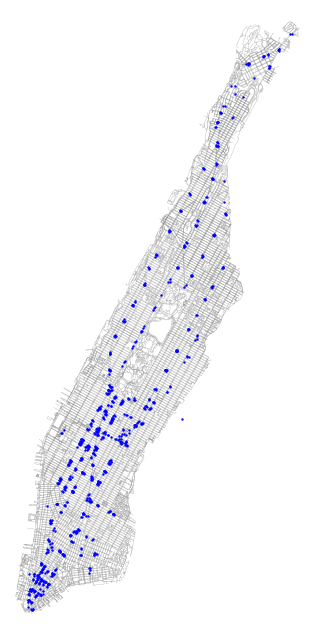

In [197]:
tags_subway = {'railway' : 'subway_entrance'}
gdf_subway = ox.features.features_from_place(place, tags_subway)
fig, ax = ox.plot.plot_graph(A, bgcolor = "white", node_size = 0, edge_linewidth = 0.1, show=False)
gdf_subway.plot(ax=ax, color='blue', markersize = 0.5)

## Comment:defines the OSM tag for subway stations,
##  downloads the corresponding point features for Manhattan,
##  plots them on top of the walking network for a quick check.

<Axes: >

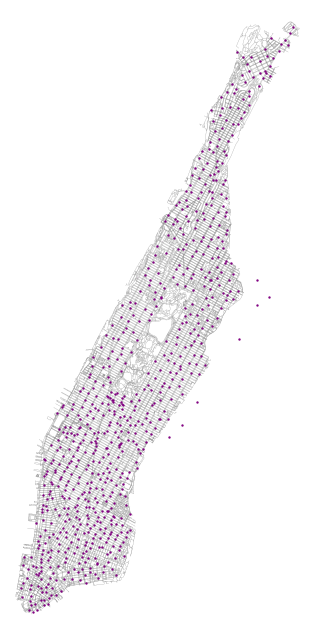

In [198]:
tags_bicycle = {'amenity' : 'bicycle_rental'}
gdf_bicycle = ox.features.features_from_place(place, tags_bicycle)
fig, ax = ox.plot.plot_graph(A, bgcolor = "white", node_size = 0, edge_linewidth = 0.1, show=False)
gdf_bicycle.plot(ax=ax, color='purple', markersize=0.5)

## Comment:defines the OSM tag for bicycle rents points,
##  downloads the corresponding point features for Manhattan,
##  plots them on top of the walking network for a quick check.

C:\Users\gjx30\AppData\Local\Temp\ipykernel_37584\435502219.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf['geometry'].centroid


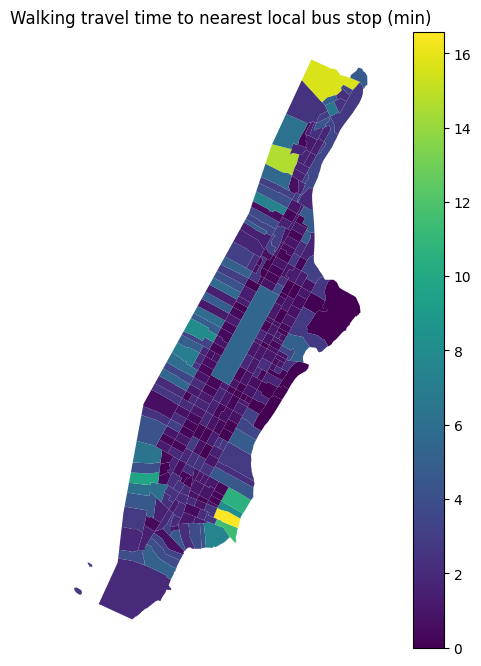

In [199]:
tract_to_buslocal = compute_mode_accessibility(gdf_buslocal, 'buslocal')
tract_buslocal = pd.merge(
    left=ny_df_tracts,
    right=tract_to_buslocal,
    on='nearest_nodes',
    how='left')
tract_buslocal['tt_buslocal_min'] = tract_buslocal['tt_buslocal_sec'] / 60

fig, ax = plt.subplots(figsize=(8, 8))
tract_buslocal.plot(
    column='tt_buslocal_min',
    legend=True,
    cmap='viridis',
    ax=ax,)
ax.set_title("Walking travel time to nearest local bus stop (min)")
ax.set_axis_off()
# Local bus accessibility
# Add minute version for readable maps
# Quick map

C:\Users\gjx30\AppData\Local\Temp\ipykernel_37584\435502219.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf['geometry'].centroid


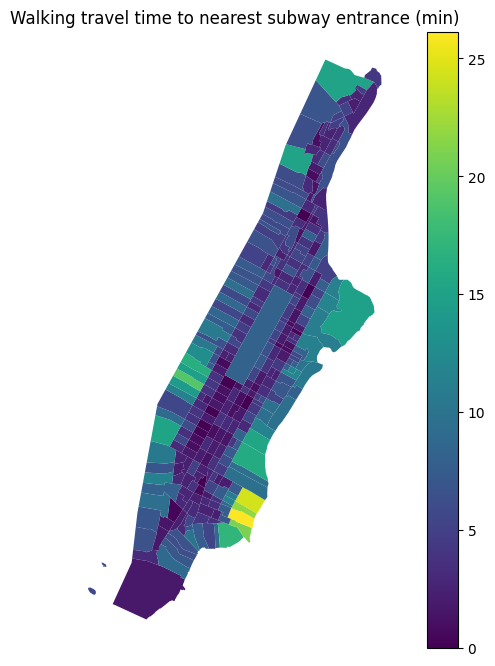

In [200]:
tract_to_subway = compute_mode_accessibility(gdf_subway, 'subway')
tract_subway = pd.merge(
    left=ny_df_tracts,
    right=tract_to_subway,
    on='nearest_nodes',
    how='left')
tract_subway['tt_subway_min'] = tract_subway['tt_subway_sec'] / 60

fig, ax = plt.subplots(figsize=(8, 8))
tract_subway.plot(
    column='tt_subway_min',
    legend=True,
    cmap='viridis',
    ax=ax,)
ax.set_title("Walking travel time to nearest subway entrance (min)")
ax.set_axis_off()
# Subway accessibility

C:\Users\gjx30\AppData\Local\Temp\ipykernel_37584\435502219.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf['geometry'].centroid


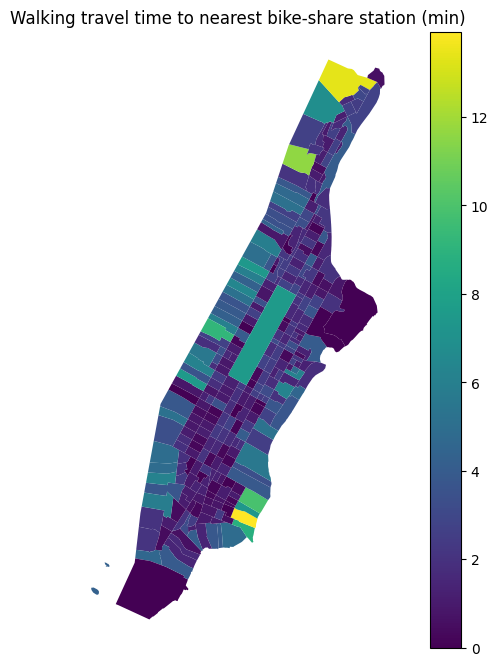

In [201]:
tract_to_bike = compute_mode_accessibility(gdf_bicycle, 'bike')
tract_bike = pd.merge(
    left=ny_df_tracts,
    right=tract_to_bike,
    on='nearest_nodes',
    how='left')
tract_bike['tt_bike_min'] = tract_bike['tt_bike_sec'] / 60

fig, ax = plt.subplots(figsize=(8, 8))
tract_bike.plot(
    column='tt_bike_min',
    legend=True,
    cmap='viridis',
    ax=ax,)
ax.set_title("Walking travel time to nearest bike-share station (min)")
ax.set_axis_off()
# Bike-share accessibility

In [202]:
# Build the tract-level master table.
# Start from ny_df_tracts (social vars + geometry), then merge in the four travel-time columns.
# We merge by GEOID (not by nearest_nodes) so that two tracts sharing the same nearest node
# both still get the correct travel time, and the merge is unambiguous.

tracts_master = ny_df_tracts.copy()

for tdf, sec_col in [
    (tract_busregional, 'tt_busregional_sec'),
    (tract_buslocal,    'tt_buslocal_sec'),
    (tract_subway,      'tt_subway_sec'),
    (tract_bike,        'tt_bike_sec'),
]:
    tracts_master = tracts_master.merge(
        tdf[['GEOID', sec_col]],
        on='GEOID',
        how='left'
    )

# Add minute versions (for plots and reporting; keep seconds for analysis)
for sec_col in ['tt_busregional_sec', 'tt_buslocal_sec', 'tt_subway_sec', 'tt_bike_sec']:
    min_col = sec_col.replace('_sec', '_min')
    tracts_master[min_col] = tracts_master[sec_col] / 60

# Sanity check
tt_cols_min = ['tt_busregional_min', 'tt_buslocal_min', 'tt_subway_min', 'tt_bike_min']
print('Shape:', tracts_master.shape)
print('NaN per mode:')
print(tracts_master[tt_cols_min].isna().sum())

tracts_master[['GEOID'] + tt_cols_min].head()

## Comment: One tract-level master table that combines social variables, tract geometry,
## and walking travel time (in seconds and minutes) to all four mobility modes.

Shape: (310, 42)
NaN per mode:
tt_busregional_min    0
tt_buslocal_min       0
tt_subway_min         0
tt_bike_min           0
dtype: int64


,GEOID,tt_busregional_min,tt_buslocal_min,tt_subway_min,tt_bike_min
0,36061016500,39.939496,0.425100,3.766654,3.927162
1,36061016600,72.053129,0.000000,1.402048,1.569635
2,36061016700,48.140616,4.821200,7.524466,6.001520
3,36061016800,68.565418,1.116586,4.509313,1.596666
4,36061016900,43.866659,0.379125,4.831410,0.000000


In [203]:
# Descriptive comparison across modes (in minutes)
tt_cols_min = ['tt_busregional_min', 'tt_buslocal_min', 'tt_subway_min', 'tt_bike_min']

desc = tracts_master[tt_cols_min].describe().round(2)
desc

,tt_busregional_min,tt_buslocal_min,tt_subway_min,tt_bike_min
count,310.00,310.00,310.00,310.00
mean,34.95,2.04,5.25,2.28
std,22.85,2.30,4.05,2.04
min,0.00,0.00,0.00,0.00
25%,14.82,0.63,2.53,0.98
50%,29.66,1.36,4.22,1.82
75%,54.80,2.65,6.82,2.83
max,91.09,16.59,26.14,13.94


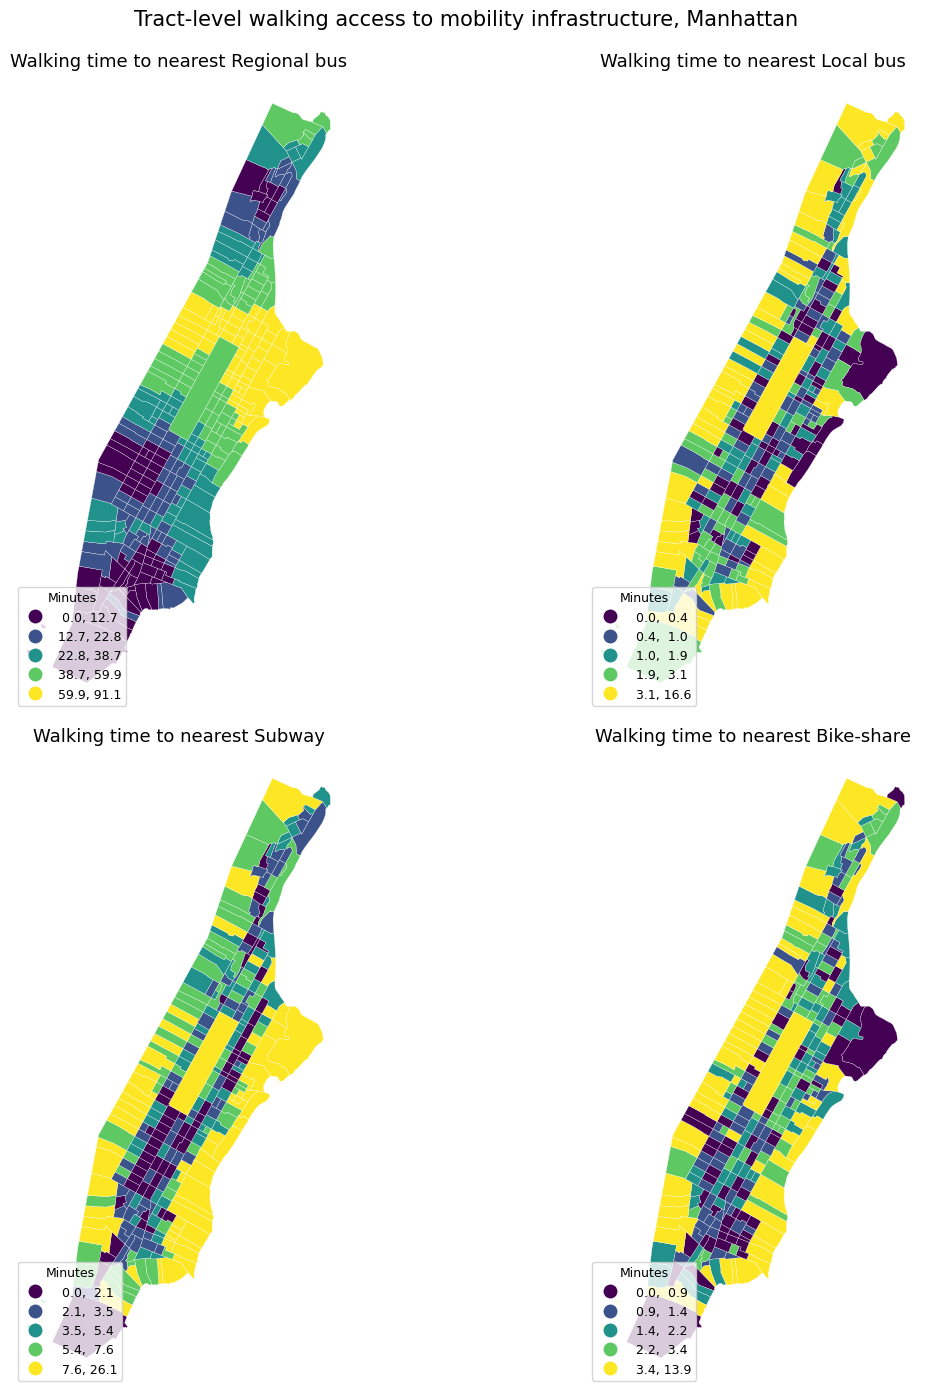

In [204]:
# 4-panel comparison map of walking time to each mode (minutes).
# Two design choices that matter for fair visual comparison:
#   1. Quantile classification (k=5) — Manhattan has long-tailed travel-time
#      distributions; quantile bins make within-Manhattan differences readable.
#   2. Each panel uses its own quantile breaks (because absolute time scales
#      differ by mode), but the legend prints the bin edges so readers can
#      compare across panels.

import warnings

mode_titles = {
    'tt_busregional_min': 'Regional bus',
    'tt_buslocal_min':    'Local bus',
    'tt_subway_min':      'Subway',
    'tt_bike_min':        'Bike-share',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

with warnings.catch_warnings():
    warnings.filterwarnings('ignore')

    for ax, (col, title) in zip(axes.flatten(), mode_titles.items()):
        tracts_master.plot(
            column=col,
            cmap='viridis',
            scheme='Quantiles',
            k=5,
            legend=True,
            legend_kwds={
                'loc': 'lower left',
                'fontsize': 9,
                'title': 'Minutes',
                'title_fontsize': 9,
                'fmt': '{:.1f}',
            },
            edgecolor='white',
            linewidth=0.2,
            ax=ax,
        )
        ax.set_title(f"Walking time to nearest {title}", fontsize=13)
        ax.set_axis_off()

plt.suptitle(
    "Tract-level walking access to mobility infrastructure, Manhattan",
    fontsize=15, y=0.995
)
plt.tight_layout()
plt.show()

## Comment: Quantile-binned choropleths make within-Manhattan inequality patterns visible
## even when one or two outlier tracts (e.g., Roosevelt Island) dominate the absolute scale.

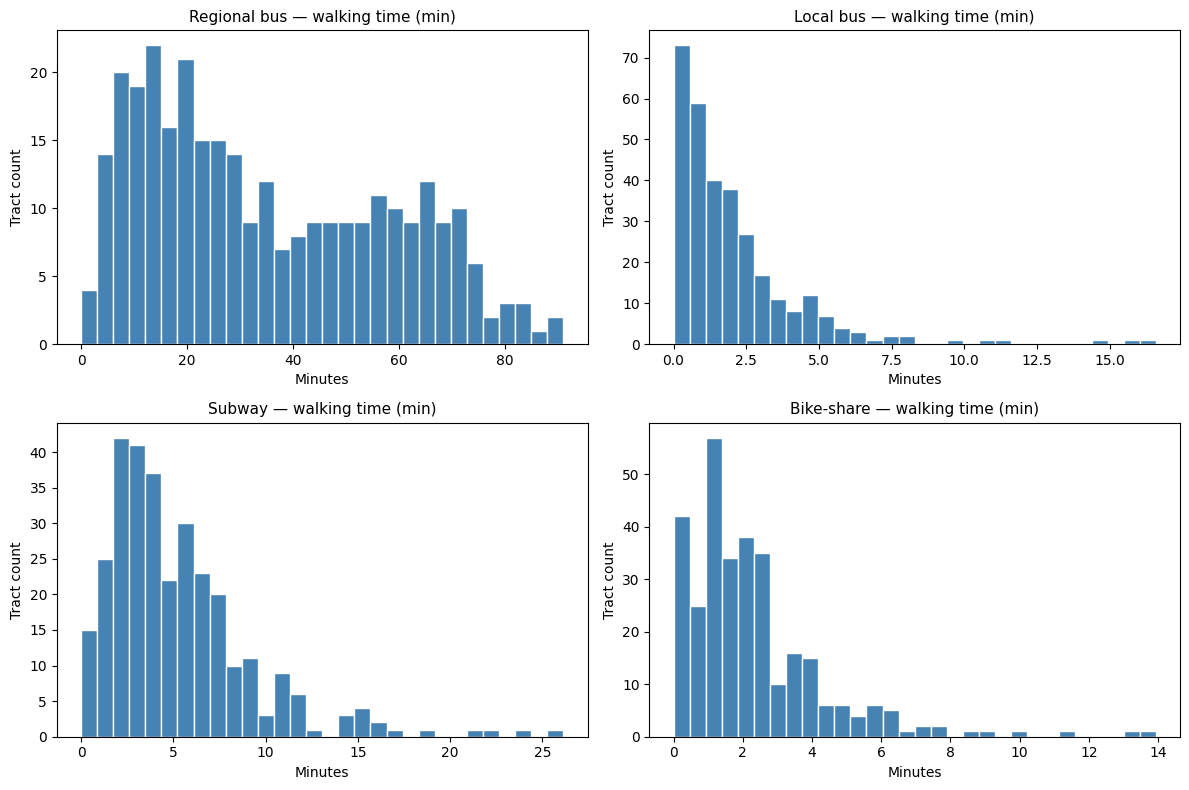

In [205]:
# Distribution of walking time per mode (helps explain the maps in writing)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

for ax, (col, title) in zip(axes.flatten(), mode_titles.items()):
    tracts_master[col].dropna().plot(
        kind='hist',
        bins=30,
        ax=ax,
        color='steelblue',
        edgecolor='white',
    )
    ax.set_title(f"{title} — walking time (min)", fontsize=11)
    ax.set_xlabel('Minutes')
    ax.set_ylabel('Tract count')

plt.tight_layout()
plt.show()

In [206]:
# Save the master tract-level table for downstream analysis.
# Drop the 'centroid' column before saving — fiona/gpkg only accepts one geometry per layer.

cols_to_drop = [c for c in ['centroid'] if c in tracts_master.columns]
tracts_to_save = tracts_master.drop(columns=cols_to_drop)

# 1. GeoPackage (preserves geometry — use this for maps and spatial weights later)
tracts_to_save.to_file('tracts_master.gpkg', driver='GPKG')
print('Saved tracts_master.gpkg')

# 2. CSV (no geometry — convenient for clustering/regression cells)
tracts_to_save.drop(columns='geometry').to_csv('tracts_master.csv', index=False)
print('Saved tracts_master.csv')

Saved tracts_master.gpkg
Saved tracts_master.csv


In [207]:
# Step G.1 - Prepare clustering input
# Inputs are the four mode-specific walking times (in minutes).
# We use minutes (not seconds) so the scaled values are easier to read,
# but since we will robust_scale them next, the unit choice doesn't affect KMeans.

# If kernel was restarted, reload from disk:
# import geopandas as gpd
# tracts_master = gpd.read_file('tracts_master.gpkg')

cluster_vars = ['tt_busregional_min', 'tt_buslocal_min', 'tt_subway_min', 'tt_bike_min']

# Drop tracts with NaN in any travel-time column (typically a few edge tracts
# like Roosevelt Island where one of the modes is unreachable on the walk graph).
cluster_input = tracts_master[['GEOID'] + cluster_vars].dropna().reset_index(drop=True)

print('Tracts kept for clustering:', len(cluster_input))
print('Tracts dropped (NaN):', len(tracts_master) - len(cluster_input))

cluster_input.head()

## Comment: cluster_input is the clean input for KMeans.
## We keep GEOID so we can join cluster labels back to tracts_master later.

Tracts kept for clustering: 310
Tracts dropped (NaN): 0


,GEOID,tt_busregional_min,tt_buslocal_min,tt_subway_min,tt_bike_min
0,36061016500,39.939496,0.425100,3.766654,3.927162
1,36061016600,72.053129,0.000000,1.402048,1.569635
2,36061016700,48.140616,4.821200,7.524466,6.001520
3,36061016800,68.565418,1.116586,4.509313,1.596666
4,36061016900,43.866659,0.379125,4.831410,0.000000


In [208]:
# Step G.2 - Scale the four travel-time variables.
# robust_scale uses median and IQR, which is less sensitive to outliers
# (e.g., Roosevelt Island has very long regional bus times).
# This is the same scaler used in Week 9 with the EJI data.

from sklearn.preprocessing import robust_scale

cluster_scaled = robust_scale(cluster_input[cluster_vars])

# Quick check: scaled medians should be ~0
import pandas as pd
pd.DataFrame(cluster_scaled, columns=cluster_vars).describe().round(2)

## Comment: cluster_scaled is a numpy array, ready to feed into KMeans.

,tt_busregional_min,tt_buslocal_min,tt_subway_min,tt_bike_min
count,310.00,310.00,310.00,310.00
mean,0.13,0.34,0.24,0.24
std,0.57,1.14,0.95,1.10
min,-0.74,-0.67,-0.98,-0.98
25%,-0.37,-0.36,-0.39,-0.46
50%,0.00,0.00,0.00,0.00
75%,0.63,0.64,0.61,0.54
max,1.54,7.54,5.12,6.52


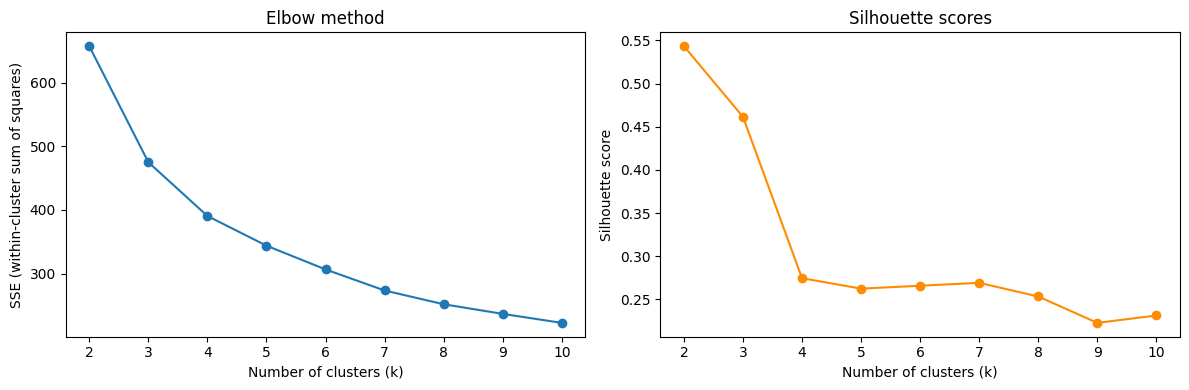

,k,sse,silhouette
0,2,657.276,0.543
1,3,475.033,0.462
2,4,390.598,0.275
3,5,343.976,0.263
4,6,306.687,0.266
5,7,273.590,0.269
6,8,251.974,0.253
7,9,236.875,0.223
8,10,222.709,0.231


In [209]:
# Step G.3 - Choose the number of clusters using elbow + silhouette.
# This combines the two diagnostics from Week 10.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

np.random.seed(0)

k_range = range(2, 11)
sse = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(cluster_scaled)
    sse.append(km.inertia_)
    silhouettes.append(silhouette_score(cluster_scaled, labels))

# Plot both diagnostics side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), sse, 'o-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('SSE (within-cluster sum of squares)')
axes[0].set_title('Elbow method')

axes[1].plot(list(k_range), silhouettes, 'o-', color='darkorange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette scores')

plt.tight_layout()
plt.show()

# Print the values so we can pick k
pd.DataFrame({'k': list(k_range), 'sse': sse, 'silhouette': silhouettes}).round(3)

## Comment: Look for an "elbow" in the SSE plot and a peak / plateau in the silhouette plot.
## In Manhattan, k usually lands around 3-5.

In [210]:
# Step G.4 - Final KMeans with chosen k (Week 9 §2 style)

np.random.seed(0)
kmeans = KMeans(n_clusters=4)   # change this if elbow/silhouette suggest a different k
k4cls = kmeans.fit(cluster_scaled)

k4cls.labels_[:10]

array([2, 2, 3, 2, 0, 2, 3, 2, 2, 2], dtype=int32)

In [211]:
# Attach labels back to cluster_input and to tracts_master via GEOID
cluster_input['k4cls'] = k4cls.labels_

# Drop old 'cluster' column if it exists from a previous run
if 'cluster' in tracts_master.columns:
    tracts_master = tracts_master.drop(columns='cluster')
if 'k4cls' in tracts_master.columns:
    tracts_master = tracts_master.drop(columns='k4cls')

tracts_master = tracts_master.merge(
    cluster_input[['GEOID', 'k4cls']],
    on='GEOID',
    how='left'
)

tracts_master['k4cls'].value_counts().sort_index()

k4cls
0    145
1      8
2    103
3     54
Name: count, dtype: int64

In [213]:
# Step G.5 - Interpret the clusters by looking at the mean travel time profile.
# This tells us what each cluster "means" in real-world terms.

ccluster_profile = tracts_master.groupby('k4cls')[cluster_vars].mean().round(2)
cluster_profile['n_tracts'] = tracts_master['k4cls'].value_counts().sort_index()
cluster_profile

## Comment: Each row is one cluster, columns show its average walking time to each mode.
## Use this to give clusters human-readable names like "subway-rich" or "transit-poor".

,tt_busregional_min,tt_buslocal_min,tt_subway_min,tt_bike_min,n_tracts
cluster,,,,,
0,58.85,1.02,4.88,2.15,145
1,28.41,12.83,20.62,10.82,8
2,18.61,1.47,3.52,1.19,103
3,34.76,4.54,9.25,4.69,54


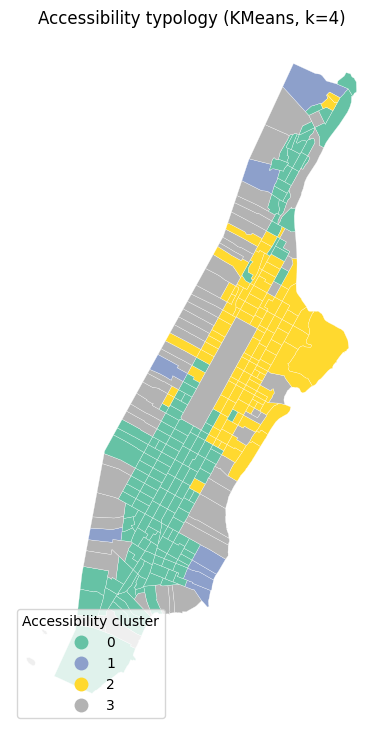

In [214]:
# Cluster map (Week 9 cell 19 style)
f, ax = plt.subplots(1, figsize=(9, 9))
tracts_master.plot(
    column='k4cls',
    categorical=True,
    legend=True,
    cmap='Set2',
    edgecolor='white',
    linewidth=0.2,
    legend_kwds={
        'loc': 'lower left',
        'title': 'Accessibility cluster',
    },
    ax=ax,
)
ax.set_title("Accessibility typology (KMeans, k=4)")
ax.set_axis_off()
plt.show()

In [215]:
# Step G.7 - DBSCAN (Week 9 §3 style)
# Unlike K-Means, DBSCAN does not assume spherical clusters and labels
# low-density points as "noise" (label = -1). Useful for spotting outlier tracts
# that K-Means forces into a cluster anyway.

from sklearn.cluster import DBSCAN

np.random.seed(0)
db = DBSCAN(eps=0.7, min_samples=5)
db_clusters = db.fit(cluster_scaled)
db_clusters.labels_[:10]

array([ 0,  0, -1,  0,  0,  0,  1,  0,  0,  0])

In [216]:
cluster_input['dbcls'] = db_clusters.labels_

if 'dbcls' in tracts_master.columns:
    tracts_master = tracts_master.drop(columns='dbcls')

tracts_master = tracts_master.merge(
    cluster_input[['GEOID', 'dbcls']],
    on='GEOID',
    how='left'
)

tracts_master['dbcls'].value_counts().sort_index()

dbcls
-1     55
 0    245
 1      5
 2      5
Name: count, dtype: int64

In [217]:
# DBSCAN cluster profile (label -1 = noise / outlier tracts)
tracts_master.groupby('dbcls')[cluster_vars].mean().round(2)

,tt_busregional_min,tt_buslocal_min,tt_subway_min,tt_bike_min
dbcls,,,,
-1,42.20,4.34,11.18,4.78
0,33.27,1.41,3.80,1.64
1,55.10,4.85,7.15,4.05
2,17.74,4.91,9.09,3.93


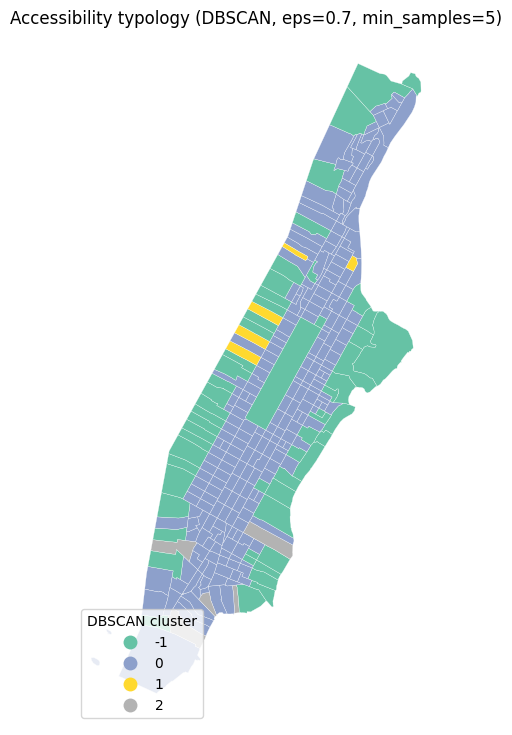

In [218]:
f, ax = plt.subplots(1, figsize=(9, 9))
tracts_master.plot(
    column='dbcls',
    categorical=True,
    legend=True,
    cmap='Set2',
    edgecolor='white',
    linewidth=0.2,
    legend_kwds={
        'loc': 'lower left',
        'title': 'DBSCAN cluster',
    },
    ax=ax,
)
ax.set_title("Accessibility typology (DBSCAN, eps=0.7, min_samples=5)")
ax.set_axis_off()
plt.show()

In [70]:
# # Diagnostic
# print("=== Travel time stats (in minutes) ===")
# print(tracts_master[['tt_busregional_min', 'tt_buslocal_min', 'tt_subway_min', 'tt_bike_min']].describe().round(2))

# print("\n=== NaN counts ===")
# print(tracts_master[['tt_busregional_min', 'tt_buslocal_min', 'tt_subway_min', 'tt_bike_min']].isna().sum())

# print("\n=== Number of regional bus features ===")
# print("gdf_busregional:", len(gdf_busregional))
# print("gdf_buslocal:", len(gdf_buslocal))
# print("gdf_subway:", len(gdf_subway))
# print("gdf_bicycle:", len(gdf_bicycle))

In [71]:
# # Check for duplicate GEOIDs in tracts_master
# print("tracts_master rows:", len(tracts_master))
# print("unique GEOIDs:", tracts_master['GEOID'].nunique())
# print("duplicate GEOIDs:", tracts_master['GEOID'].duplicated().sum())

# # Show some duplicates
# dups = tracts_master[tracts_master['GEOID'].duplicated(keep=False)].sort_values('GEOID')
# dups[['GEOID', 'tt_busregional_min', 'tt_buslocal_min', 'tt_subway_min', 'tt_bike_min']].head(20)

In [72]:
# # Check tract characteristics
# print("=== Population distribution ===")
# print(tracts_master['Total Population'].describe())

# print("\n=== Tracts with zero or tiny population ===")
# zero_pop = tracts_master[tracts_master['Total Population'] <= 50]
# print(f"Tracts with population <= 50: {len(zero_pop)}")
# print(zero_pop[['GEOID', 'Total Population', 'tt_busregional_min', 'tt_buslocal_min', 'tt_subway_min', 'tt_bike_min']].head(20))

# print("\n=== Geometry check ===")
# print("Null geometries:", tracts_master.geometry.isna().sum())
# print("Empty geometries:", tracts_master.geometry.is_empty.sum())

In [219]:
# Step H.1 - Prepare regression input
# Y: walking travel time to each of the four modes (in minutes)
# X: tract-level sociodemographic variables (social conditions only;
#    we do NOT include cluster labels, since cluster is derived from Y itself).

reg_vars_y = ['tt_busregional_min', 'tt_buslocal_min', 'tt_subway_min', 'tt_bike_min']
reg_vars_x = ['log_per_capita_income', 'poverty_rate_pct', 'nonwhite_share_pct',
              'log_pop_density', 'renter_share_pct']

# Build a clean regression dataframe (drop NaN, drop zero-population tracts since
# their social variables are meaningless for parks/water/airports)
reg_df = tracts_master[
    (tracts_master['Total Population'] > 50)
][['GEOID'] + reg_vars_y + reg_vars_x].dropna().reset_index(drop=True)

print('Tracts kept for regression:', len(reg_df))
print('Tracts dropped:', len(tracts_master) - len(reg_df))

reg_df.describe().round(2)

## Comment: reg_df is the cleaned input for OLS.
## Predictors: log_per_capita_income (log-transformed), poverty_rate_pct,
## nonwhite_share_pct, log_pop_density, renter_share_pct.
## We exclude zero/low-population tracts (parks, water) and any rows with missing data.

Tracts kept for regression: 301
Tracts dropped: 9


,tt_busregional_min,tt_buslocal_min,tt_subway_min,tt_bike_min,log_per_capita_income,poverty_rate_pct,nonwhite_share_pct,log_pop_density,renter_share_pct
count,301.00,301.00,301.00,301.00,301.00,301.00,301.00,301.00,301.00
mean,35.03,1.97,5.17,2.21,11.11,15.03,43.10,10.30,75.86
std,22.73,2.18,4.01,1.92,0.73,11.93,25.66,0.76,19.94
min,0.00,0.00,0.00,0.00,8.44,0.00,1.41,6.04,15.56
25%,15.42,0.62,2.50,0.98,10.56,6.08,21.40,10.07,62.92
50%,29.63,1.32,4.18,1.81,11.23,11.04,34.63,10.47,80.29
75%,55.27,2.53,6.79,2.77,11.71,21.00,67.85,10.71,92.68
max,91.09,16.59,26.14,13.94,12.62,60.39,93.51,11.70,100.00


In [220]:
# Step H.2 - Check correlation among predictors (Week 6_2 style)
# Strong correlation (>0.8) between predictors causes multicollinearity issues.

reg_df[reg_vars_x].corr().round(2)

,log_per_capita_income,poverty_rate_pct,nonwhite_share_pct,log_pop_density,renter_share_pct
log_per_capita_income,1.00,-0.82,-0.84,-0.13,-0.66
poverty_rate_pct,-0.82,1.00,0.75,-0.05,0.57
nonwhite_share_pct,-0.84,0.75,1.00,0.03,0.61
log_pop_density,-0.13,-0.05,0.03,1.00,0.02
renter_share_pct,-0.66,0.57,0.61,0.02,1.00


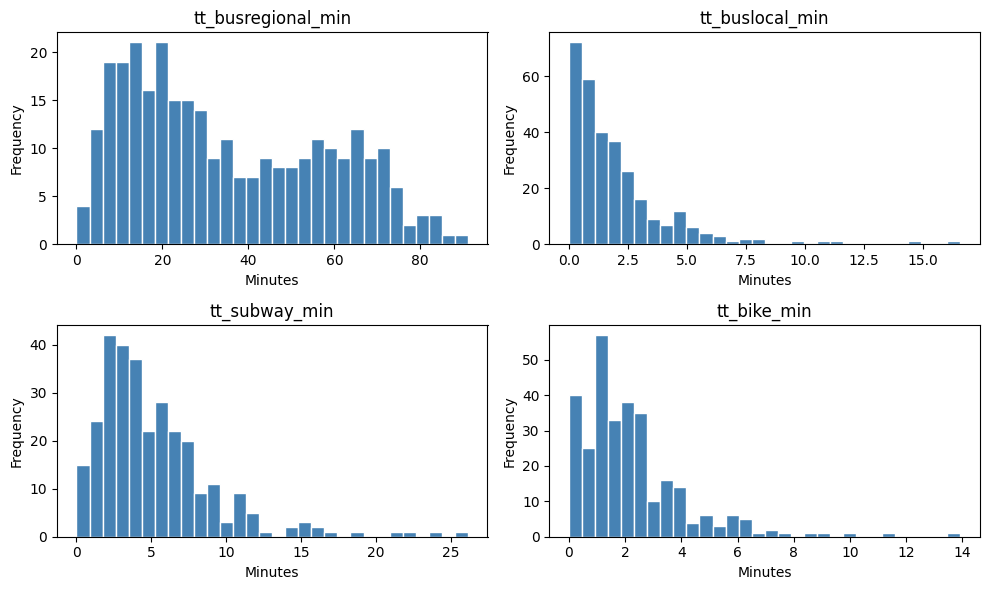

In [221]:
# And check that Y variables look roughly bell-shaped (or use log if heavily skewed)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col in zip(axes.flatten(), reg_vars_y):
    reg_df[col].plot(kind='hist', bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Minutes')

plt.tight_layout()
plt.show()

In [222]:
# Step H.3.1 - OLS for regional bus walking time
import statsmodels.formula.api as smf

model_busregional = smf.ols(
    formula='tt_busregional_min ~ log_per_capita_income + poverty_rate_pct + nonwhite_share_pct + log_pop_density + renter_share_pct',
    data=reg_df
).fit()
model_busregional.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     tt_busregional_min   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     7.688
Date:                Sat, 02 May 2026   Prob (F-statistic):           8.21e-07
Time:                        19:05:38   Log-Likelihood:                -1348.4
No. Observations:                 301   AIC:                             2709.
Df Residuals:                     295   BIC:                             2731.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -24.3699     59.276     -0.411      0.681    -141.027      92.287
log_per_capita_income    -1.3811      4.090     -0.338      0.736      -9.430       6.668
poverty_rate_pct          0.1609      0.193      0.834      0.405      -0.219       0.540
nonwhite_share_pct        0.1470      0.093      1.575      0.116      -0.037       0.331
log_pop_density           7.9327      1.742      4.554      0.000       4.504      11.361
renter_share_pct         -0.2072      0.084     -2.461      0.014      -0.373      -0.042
==============================================================================
Omnibus:                       32.731   Durbin-Watson:                   0.856
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               13.704
Skew:                           0.303   Prob(JB):                      0.00106
Kurtosis:                       2.148   Cond. No.                     4.50e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [223]:
# Step H.3.2 - OLS for local bus walking time
model_buslocal = smf.ols(
    formula='tt_buslocal_min ~ log_per_capita_income + poverty_rate_pct + nonwhite_share_pct + log_pop_density + renter_share_pct',
    data=reg_df
).fit()
model_buslocal.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        tt_buslocal_min   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     3.647
Date:                Sat, 02 May 2026   Prob (F-statistic):            0.00323
Time:                        19:05:38   Log-Likelihood:                -651.75
No. Observations:                 301   AIC:                             1316.
Df Residuals:                     295   BIC:                             1338.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                16.5618      5.858      2.827      0.005       5.033      28.090
log_per_capita_income    -0.8937      0.404     -2.211      0.028      -1.689      -0.098
poverty_rate_pct          0.0162      0.019      0.852      0.395      -0.021       0.054
nonwhite_share_pct       -0.0139      0.009     -1.504      0.134      -0.032       0.004
log_pop_density          -0.3664      0.172     -2.128      0.034      -0.705      -0.028
renter_share_pct         -0.0070      0.008     -0.839      0.402      -0.023       0.009
==============================================================================
Omnibus:                      186.320   Durbin-Watson:                   1.754
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1498.370
Skew:                           2.497   Prob(JB):                         0.00
Kurtosis:                      12.723   Cond. No.                     4.50e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [224]:
# Step H.3.3 - OLS for subway walking time
model_subway = smf.ols(
    formula='tt_subway_min ~ log_per_capita_income + poverty_rate_pct + nonwhite_share_pct + log_pop_density + renter_share_pct',
    data=reg_df
).fit()
model_subway.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          tt_subway_min   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     2.344
Date:                Sat, 02 May 2026   Prob (F-statistic):             0.0415
Time:                        19:05:49   Log-Likelihood:                -838.43
No. Observations:                 301   AIC:                             1689.
Df Residuals:                     295   BIC:                             1711.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                12.3632     10.891      1.135      0.257      -9.071      33.798
log_per_capita_income    -0.6316      0.751     -0.840      0.401      -2.111       0.847
poverty_rate_pct          0.0749      0.035      2.113      0.035       0.005       0.145
nonwhite_share_pct       -0.0295      0.017     -1.721      0.086      -0.063       0.004
log_pop_density           0.0216      0.320      0.068      0.946      -0.608       0.652
renter_share_pct         -0.0033      0.015     -0.215      0.830      -0.034       0.027
==============================================================================
Omnibus:                      109.883   Durbin-Watson:                   1.416
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              334.151
Skew:                           1.649   Prob(JB):                     2.75e-73
Kurtosis:                       6.971   Cond. No.                     4.50e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [225]:
# Step H.3.4 - OLS for bike-share walking time
model_bike = smf.ols(
    formula='tt_bike_min ~ log_per_capita_income + poverty_rate_pct + nonwhite_share_pct + log_pop_density + renter_share_pct',
    data=reg_df
).fit()
model_bike.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            tt_bike_min   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.683
Date:                Sat, 02 May 2026   Prob (F-statistic):              0.138
Time:                        19:05:51   Log-Likelihood:                -618.65
No. Observations:                 301   AIC:                             1249.
Df Residuals:                     295   BIC:                             1272.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                14.0044      5.248      2.669      0.008       3.677      24.332
log_per_capita_income    -0.7391      0.362     -2.041      0.042      -1.452      -0.026
poverty_rate_pct         -0.0011      0.017     -0.067      0.947      -0.035       0.032
nonwhite_share_pct       -0.0105      0.008     -1.275      0.203      -0.027       0.006
log_pop_density          -0.2661      0.154     -1.725      0.086      -0.570       0.037
renter_share_pct         -0.0049      0.007     -0.653      0.514      -0.020       0.010
==============================================================================
Omnibus:                      136.775   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              622.358
Skew:                           1.901   Prob(JB):                    7.19e-136
Kurtosis:                       8.930   Cond. No.                     4.50e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [226]:
# Step H.4 - Side-by-side coefficient and p-value table across the four modes
import pandas as pd

models = {
    'tt_busregional_min': model_busregional,
    'tt_buslocal_min':    model_buslocal,
    'tt_subway_min':      model_subway,
    'tt_bike_min':        model_bike,
}

coef_table = pd.DataFrame({y: m.params  for y, m in models.items()}).round(4)
pval_table = pd.DataFrame({y: m.pvalues for y, m in models.items()}).round(4)

r2_row = pd.Series({y: m.rsquared for y, m in models.items()}, name='R_squared').round(3)
n_row  = pd.Series({y: int(m.nobs) for y, m in models.items()}, name='N')

print('=== Coefficients ===')
print(coef_table)
print('\n=== P-values ===')
print(pval_table)
print('\n=== Model fit ===')
print(pd.DataFrame([r2_row, n_row]))

## Comment: This table summarizes the four single-mode OLS regressions side by side.
## A coefficient is in the 'expected unequal' direction if income is negative,
## or poverty / nonwhite is positive; combined with p < 0.05, this is a key finding.

=== Coefficients ===
                       tt_busregional_min  tt_buslocal_min  tt_subway_min  \
Intercept                        -24.3699          16.5618        12.3632   
log_per_capita_income             -1.3811          -0.8937        -0.6316   
poverty_rate_pct                   0.1609           0.0162         0.0749   
nonwhite_share_pct                 0.1470          -0.0139        -0.0295   
log_pop_density                    7.9327          -0.3664         0.0216   
renter_share_pct                  -0.2072          -0.0070        -0.0033   

                       tt_bike_min  
Intercept                  14.0044  
log_per_capita_income      -0.7391  
poverty_rate_pct           -0.0011  
nonwhite_share_pct         -0.0105  
log_pop_density            -0.2661  
renter_share_pct           -0.0049  

=== P-values ===
                       tt_busregional_min  tt_buslocal_min  tt_subway_min  \
Intercept                          0.6813           0.0050         0.2572   
log_per_